In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 로드 및 가이드 기반 피처 엔지니어링 (동일)
input_file = '/Users/user/Desktop/bitamin/26_winter_proj/data/KFG/KFG_final_2.csv'
df = pd.read_csv(input_file)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True).fillna(method='ffill').fillna(method='bfill')

def build_advanced_features(df):
    df = df.copy()
    '''
    추후 예측에 사용할 변수 미리 생성
    '''
    df['neg_z_inv'] = -df['neg_z']
    df['sent_std_inv'] = -df['sent_std']
    df['sent_energy'] = df['sent_strength_w'] * df['sent_norm_w']
    df['sent_norm_diff'] = df['sent_norm_w'].diff()
    df['neg_z_diff'] = df['neg_z'].diff()
    df['sent_norm_ma5'] = df['sent_norm_w'].rolling(5).mean()
    df['neg_z_ma5'] = df['neg_z'].rolling(5).mean()
    # 20일 누적수익률 (모멘텀)
    r = df['log_return_t+1'].shift(1)

    df['ret_20d'] = r.rolling(20).sum()
    df['vol_20d'] = r.rolling(20).std()

    # 모멘텀 더미 (상승장=1, 하락장=0)
    df['regime_mom'] = (df['ret_20d'] > 0).astype(int)

    # 고변동성 더미
    vol_threshold = df['vol_20d'].rolling(252).median()
    df['regime_vol'] = (df['vol_20d'] > vol_threshold).astype(int)

    # -----------------------------
    # Controlled Lag Expansion (과적합 최소화 설계)
    # -----------------------------
    sub_cols = [f'sub_index{i}' for i in range(1, 8)]

    # sub_index는 lag1~2만
    for col in sub_cols:
        for lag in range(1, 3):
            df[f'{col}_lag{lag}'] = df[col].shift(lag)

    # KFGI는 lag1~3
    # (KFGI는 create_kfgi 이후 생성되므로 여기선 원본 sub 기반만 생성)
    # sent_norm_w는 lag1~3
    for lag in range(1, 4):
        df[f'sent_norm_w_lag{lag}'] = df['sent_norm_w'].shift(lag)

    # 5일 누적 수익률 (단기 모멘텀)
    df['ret_5d'] = df['log_return_t+1'].shift(1).rolling(5).sum()

    # 5일 변동성 (단기 변동성)
    df['vol_5d'] = df['log_return_t+1'].shift(1).rolling(5).std()

    df['dayofweek'] = df['date'].dt.dayofweek
    df['month'] = df['date'].dt.month
    df['target_reg'] = df['log_return_t+1']
    df['target_cls'] = (df['log_return_t+1'] > 0).astype(int)
    df['sample_weight'] = np.log1p(df['effective_n'])

    return df.dropna().reset_index(drop=True)

# 앞으로 사용하게 될 dataset
df_eng = build_advanced_features(df)

# 2. K-FGI 지수 생성 (Ridge) , 100 - kfgi
def create_kfgi(df, train_end='2024-12-31'):
    train_mask = df['date'] <= train_end
    core_feats = [f'sub_index{i}' for i in range(1, 8)] + \
                 ['sent_norm_w', 'sent_energy', 'sent_std_inv', 'neg_z_inv']
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(df.loc[train_mask, core_feats])
    X_all_scaled = scaler.transform(df[core_feats])
    ridge = RidgeCV(alphas=[0.1, 1.0, 10.0]).fit(X_train_scaled, df.loc[train_mask, 'target_reg'])
    w = ridge.coef_ / np.sum(np.abs(ridge.coef_))
    raw = X_all_scaled @ w
    p1, p99 = np.percentile(raw[train_mask], [1, 99])
    df['K_FGI'] = 100 * (np.clip(raw, p1, p99) - p1) / (p99 - p1)
    return df, core_feats, w

df_fgi, core_feats, w = create_kfgi(df_eng)

df_fgi['KFGI'] = 100 - df_fgi['K_FGI']
df_fgi['KFGI_x_regime'] = df_fgi['KFGI'] * df_fgi['regime_mom']
df_fgi['sent_x_regime'] = df_fgi['sent_norm_w'] * df_fgi['regime_mom']


'''
예측 모델 심화
'''
# 타겟 변경
df_fgi['target_reg_3d'] = df_fgi['log_return_t+1'].shift(-2).rolling(3).sum()
df_fgi['target_reg_5d'] = df_fgi['log_return_t+1'].shift(-4).rolling(5).sum()

df_fgi = df_fgi.dropna().reset_index(drop=True)


from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

 # -----------------------------
 # Controlled Feature Set (약 30개 내외 유지)
 # -----------------------------
features = []

# sub_index lag1~2
for i in range(1, 8):
    for lag in range(1, 3):
        features.append(f'sub_index{i}_lag{lag}')

# sentiment lag
for lag in range(1, 4):
    features.append(f'sent_norm_w_lag{lag}')

# 기존 engineered 변수
features += [
    'sent_energy',
    'sent_std_inv',
    'neg_z_inv',
    'sent_norm_diff',
    'neg_z_diff',
    'sent_norm_ma5',
    'neg_z_ma5',
    'ret_5d',
    'vol_5d',
    'KFGI',
    'regime_mom',
    'regime_vol',
    'KFGI_x_regime',
    'sent_x_regime',
    'dayofweek',
    'month'
]

X = df_fgi[features].values
y = df_fgi['target_reg'].values

tscv = TimeSeriesSplit(n_splits=5)
window_size = 750

preds_all = []
actual_all = []
dates_all = []

# -----------------------------
# 2️⃣ Walk-forward CV
# -----------------------------
print("\n===== Rolling Window Performance =====")
for i in range(window_size, len(X)):
    train_idx = range(i - window_size, i)
    test_idx = i    

    X_train = X[list(train_idx)]
    y_train = y[list(train_idx)]
    X_test = X[test_idx:test_idx+1]
    y_test = y[test_idx]

    # 🔴 scaler는 반드시 fold 안에서 fit
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = Ridge(alpha=1.0)
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)[0]

    preds_all.append(pred)
    actual_all.append(y_test)
    dates_all.append(df_fgi.iloc[test_idx]['date'])

preds_all = np.array(preds_all)
actual_all = np.array(actual_all)


===== Rolling Window Performance =====


/var/folders/ly/x0qvvd5d6_l1xs8p1h7k0zqw0000gn/T/ipykernel_13026/2564343452.py:13: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.sort_values('date').reset_index(drop=True).fillna(method='ffill').fillna(method='bfill')


In [2]:
#%%
import numpy as np
import pandas as pd

df_test = df_fgi.copy()
df_test = df_test.sort_values("date").reset_index(drop=True)

# 1일 수익률 기준 (5일이면 target_reg_5d로 바꿔도 됨)
df_test["ret"] = df_test["target_reg"]

# Buy & Hold
df_test["bh_ret"] = df_test["ret"]

#%%
low_th = df_test["KFGI"].quantile(0.2)
high_th = df_test["KFGI"].quantile(0.8)

df_test["signal_fgi"] = 0
df_test.loc[df_test["KFGI"] <= low_th, "signal_fgi"] = 1
df_test.loc[df_test["KFGI"] >= high_th, "signal_fgi"] = 0

df_test["fgi_ret"] = df_test["signal_fgi"] * df_test["ret"]

print("FGI Signal Frequency:", df_test["signal_fgi"].mean())

#%%
np.random.seed(42)

p = df_test["signal_fgi"].mean()

df_test["signal_random"] = np.random.binomial(1, p, size=len(df_test))
df_test["random_ret"] = df_test["signal_random"] * df_test["ret"]

FGI Signal Frequency: 0.2


In [3]:
#%%
def performance(df, col, name):

    ret = df[col]

    ann_ret = ret.mean() * 252
    ann_vol = ret.std() * np.sqrt(252)
    sharpe = ann_ret / (ann_vol + 1e-9)

    cum = np.exp(ret.cumsum())
    rolling_max = cum.cummax()
    drawdown = cum / rolling_max - 1
    mdd = drawdown.min()

    print(f"\n===== {name} =====")
    print(f"Annual Return: {ann_ret:.3f}")
    print(f"Sharpe: {sharpe:.3f}")
    print(f"Max Drawdown: {mdd:.3f}")

    return cum

#%%
cum_fgi = performance(df_test, "fgi_ret", "FGI Strategy")
cum_bh = performance(df_test, "bh_ret", "Buy & Hold")
cum_random = performance(df_test, "random_ret", "Random Walk Strategy")

#%%
df_early = df_test[df_test["date"] < "2025-01-01"]
df_2025 = df_test[df_test["date"] >= "2025-01-01"]

print("\n--- 2022~2024 ---")
performance(df_early, "fgi_ret", "FGI")
performance(df_early, "bh_ret", "Buy & Hold")
performance(df_early, "random_ret", "Random")

print("\n--- 2025 ---")
performance(df_2025, "fgi_ret", "FGI")
performance(df_2025, "bh_ret", "Buy & Hold")
performance(df_2025, "random_ret", "Random")


===== FGI Strategy =====
Annual Return: 0.109
Sharpe: 1.160
Max Drawdown: -0.083

===== Buy & Hold =====
Annual Return: 0.113
Sharpe: 0.594
Max Drawdown: -0.210

===== Random Walk Strategy =====
Annual Return: 0.070
Sharpe: 0.684
Max Drawdown: -0.098

--- 2022~2024 ---

===== FGI =====
Annual Return: 0.114
Sharpe: 1.258
Max Drawdown: -0.065

===== Buy & Hold =====
Annual Return: -0.049
Sharpe: -0.273
Max Drawdown: -0.210

===== Random =====
Annual Return: 0.032
Sharpe: 0.314
Max Drawdown: -0.098

--- 2025 ---

===== FGI =====
Annual Return: 0.094
Sharpe: 0.919
Max Drawdown: -0.083

===== Buy & Hold =====
Annual Return: 0.574
Sharpe: 2.651
Max Drawdown: -0.141

===== Random =====
Annual Return: 0.178
Sharpe: 1.696
Max Drawdown: -0.042


673    1.000000
674    1.000000
675    1.001390
676    1.001390
677    1.001390
         ...   
905    1.200483
906    1.182164
907    1.182164
908    1.182164
909    1.182164
Name: random_ret, Length: 237, dtype: float64

<Axes: xlabel='date'>

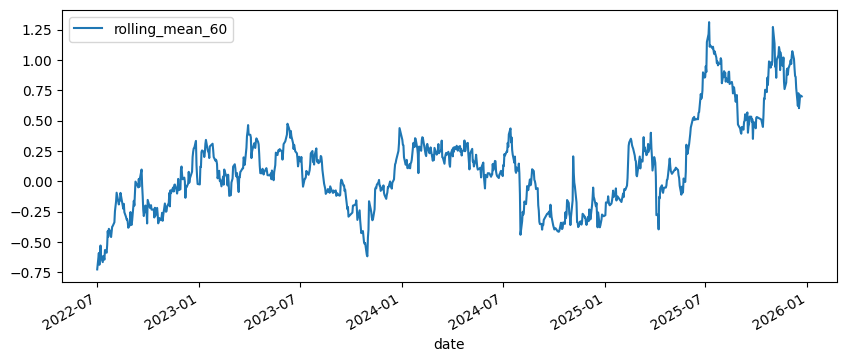

In [4]:
df_test["rolling_mean_60"] = df_test["ret"].rolling(60).mean() * 252
df_test.plot(x="date", y="rolling_mean_60", figsize=(10,4))

In [6]:
from scipy import stats

window = df_test["ret"].iloc[-60:]
t_stat, p_val = stats.ttest_1samp(window, 0)
print(t_stat, p_val)

cum = np.exp(df_test["ret"].cumsum())
print(cum)

1.2434878766780961 0.2186065209473199
0      0.985678
1      0.987335
2      0.984669
3      0.975039
4      0.993221
         ...   
905    1.483132
906    1.460500
907    1.470020
908    1.501238
909    1.505402
Name: ret, Length: 910, dtype: float64


In [8]:
#%%
import numpy as np
import pandas as pd

df = df_fgi.copy()
df = df.sort_values("date").reset_index(drop=True)

# 1일 수익률
df["ret"] = df["target_reg"]

# Buy & Hold
df["bh_ret"] = df["ret"]

#%%
# 과거 60일 누적수익률
df["ret_60d"] = df["ret"].shift(1).rolling(60).sum()

# Drift Regime 정의
df["drift_regime"] = (df["ret_60d"] > 0).astype(int)

# FGI 단독 임계값 전략
low_th = df["KFGI"].quantile(0.2)
high_th = df["KFGI"].quantile(0.8)

df["signal_fgi"] = 0
df.loc[df["KFGI"] <= low_th, "signal_fgi"] = 1
df.loc[df["KFGI"] >= high_th, "signal_fgi"] = 0

df["fgi_ret"] = df["signal_fgi"] * df["ret"]

# 레짐 스위칭 전략
df["switch_ret"] = 0

# Drift=1 → BH
df.loc[df["drift_regime"] == 1, "switch_ret"] = df["bh_ret"]

# Drift=0 → FGI
df.loc[df["drift_regime"] == 0, "switch_ret"] = df["fgi_ret"]

# 랜덤 전략 (비교용)
np.random.seed(42)

p = df["signal_fgi"].mean()
df["signal_random"] = np.random.binomial(1, p, size=len(df))
df["random_ret"] = df["signal_random"] * df["ret"]

/var/folders/ly/x0qvvd5d6_l1xs8p1h7k0zqw0000gn/T/ipykernel_13026/3061546704.py:35: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-7.96307355e-03  5.16142744e-03 -8.75498163e-03 -1.22119579e-02
  2.95212406e-03 -1.85224773e-02 -6.18505572e-03 -1.08718406e-02
 -4.33420486e-03 -1.60836370e-02 -3.33178724e-03 -8.05901755e-03
 -1.86176656e-03  1.18575428e-02 -1.84314124e-02  1.49001394e-03
  6.73130954e-03 -2.26921842e-02 -1.95053617e-02 -4.80943629e-03
  3.83575326e-03  1.11184954e-02  2.59574589e-02  4.76443697e-04
  3.48982701e-03  2.35785769e-03  8.83573865e-03  5.75435932e-03
 -8.56625001e-03 -4.66330928e-03  5.06249160e-03  6.24844985e-03
  1.38108223e-02  1.63688358e-02  6.20677305e-03 -1.35983727e-02
 -1.04153294e-02  1.01418750e-02  7.75821794e-03  4.65523098e-03
 -1.71638767e-02  5.52977953e-03  1.29394858e-02 -8.53950378e-04
 -4.76244273e-03 -1.54247225e-02 -9.85253642e-03  1.59385970e-03
  1.5628

In [9]:
#%%
def performance(df, col, name):

    ret = df[col].dropna()

    ann_ret = ret.mean() * 252
    ann_vol = ret.std() * np.sqrt(252)
    sharpe = ann_ret / (ann_vol + 1e-9)

    cum = np.exp(ret.cumsum())
    rolling_max = cum.cummax()
    drawdown = cum / rolling_max - 1
    mdd = drawdown.min()

    print(f"\n===== {name} =====")
    print(f"Annual Return: {ann_ret:.3f}")
    print(f"Sharpe: {sharpe:.3f}")
    print(f"Max Drawdown: {mdd:.3f}")

    return cum

In [10]:
#%%
performance(df, "bh_ret", "Buy & Hold")
performance(df, "fgi_ret", "FGI Strategy")
performance(df, "switch_ret", "Regime Switching Strategy")
performance(df, "random_ret", "Random Strategy")


===== Buy & Hold =====
Annual Return: 0.113
Sharpe: 0.594
Max Drawdown: -0.210

===== FGI Strategy =====
Annual Return: 0.109
Sharpe: 1.160
Max Drawdown: -0.083

===== Regime Switching Strategy =====
Annual Return: 0.165
Sharpe: 1.061
Max Drawdown: -0.141

===== Random Strategy =====
Annual Return: 0.070
Sharpe: 0.684
Max Drawdown: -0.098


0      1.000000
1      1.001680
2      1.001680
3      1.001680
4      1.001680
         ...   
905    1.306621
906    1.286683
907    1.286683
908    1.286683
909    1.286683
Name: random_ret, Length: 910, dtype: float64

In [11]:
#%%
df_early = df[df["date"] < "2025-01-01"]
df_2025 = df[df["date"] >= "2025-01-01"]

print("\n--- 2022~2024 ---")
performance(df_early, "bh_ret", "BH")
performance(df_early, "fgi_ret", "FGI")
performance(df_early, "switch_ret", "Switch")

print("\n--- 2025 ---")
performance(df_2025, "bh_ret", "BH")
performance(df_2025, "fgi_ret", "FGI")
performance(df_2025, "switch_ret", "Switch")


--- 2022~2024 ---

===== BH =====
Annual Return: -0.049
Sharpe: -0.273
Max Drawdown: -0.210

===== FGI =====
Annual Return: 0.114
Sharpe: 1.258
Max Drawdown: -0.065

===== Switch =====
Annual Return: 0.054
Sharpe: 0.413
Max Drawdown: -0.112

--- 2025 ---

===== BH =====
Annual Return: 0.574
Sharpe: 2.651
Max Drawdown: -0.141

===== FGI =====
Annual Return: 0.094
Sharpe: 0.919
Max Drawdown: -0.083

===== Switch =====
Annual Return: 0.480
Sharpe: 2.294
Max Drawdown: -0.141


673    1.000000
674    1.000000
675    1.000000
676    1.000000
677    1.000000
         ...   
905    1.546629
906    1.523027
907    1.532956
908    1.565510
909    1.569852
Name: switch_ret, Length: 237, dtype: float64